# Execution info and server info inside tools

Access execution identity (thread ID, run ID) via runtime.execution_info, and server-specific metadata (assistant ID, authenticated user) via runtime.server_info when running on LangGraph Server:

In [1]:
import os

from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from pprint import pprint
from langchain.tools import tool

from langchain.chat_models import init_chat_model
from rich import print as rprint

In [3]:
model_free = init_chat_model("openai/gpt-oss-20b",
                        api_key=os.environ["GROQ_API_KEY"],
                        model_provider="groq",
                        # base_url="https://api.groq.com/openai/v1",
                        max_tokens=10000, temperature=0.0)

model_basic = init_chat_model("openrouter/free",
                        api_key=os.environ["OPENROUTER_API_KEY"],
                        model_provider="openrouter",
                        base_url="https://openrouter.ai/api/v1",
                        max_tokens=1000, temperature=0.0)

model_medium = init_chat_model("openai/gpt-5.6-luna",
                        api_key=os.environ["OPENROUTER_API_KEY"],
                        model_provider="openrouter",
                        base_url="https://openrouter.ai/api/v1",
                        max_tokens=10000, temperature=0.0)

model_advanced = init_chat_model("openai/gpt-5.6-luna-pro",
                        api_key=os.environ["OPENROUTER_API_KEY"],
                        model_provider="openrouter",
                        base_url="https://openrouter.ai/api/v1",
                        max_tokens=10000, temperature=0.0)

model_safety = init_chat_model("nvidia/nemotron-3.5-content-safety:free",
                        api_key=os.environ["OPENROUTER_API_KEY"],
                        model_provider="openrouter",
                        base_url="https://openrouter.ai/api/v1",
                        max_tokens=10000, temperature=0.0)



In [8]:
from langchain.tools import tool, ToolRuntime

@tool
def context_aware_tool(runtime: ToolRuntime) -> str:
    """A tool that uses execution and server info."""
    # Access thread and run IDs
    info = runtime.execution_info
    print(f"Thread: {info.thread_id}, Run: {info.run_id}")

    # Access server info (only available on LangGraph Server)
    server = runtime.server_info
    if server is not None:
        print(f"Assistant: {server.assistant_id}")
        if server.user is not None:
            print(f"User: {server.user.identity}")

    return "done"


In [10]:
from dataclasses import dataclass

from langchain.agents import create_agent

from langgraph.store.memory import InMemoryStore 
from langgraph.checkpoint.memory import InMemorySaver


checkpointer = InMemorySaver()
store = InMemoryStore()

@dataclass
class Context:
    user_name: str

agent = create_agent(
    model=model_advanced,
    tools=[context_aware_tool],
    store = store,
    checkpointer=checkpointer,
    context_schema=Context ,
)


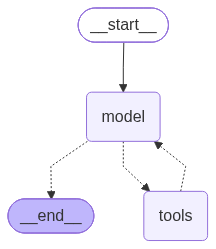

In [11]:
agent

In [14]:
import uuid
result= agent.invoke(
    {"messages": [{"role": "user", "content": "My name is Sunj, Run the context aware tool"}]},
    {"configurable": {"thread_id": str(uuid.uuid4())}},
    context=Context(user_name="Sunj")
)

c:\Users\socgen\ML\agentic_ai_and_ops\.venv\Lib\site-packages\pydantic\functional_validators.py:835: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='context', input_value=Context(user_name='Sunj'), input_type=Context])
  function=lambda v, h: h(v), schema=original_schema
c:\Users\socgen\ML\agentic_ai_and_ops\.venv\Lib\site-packages\pydantic\main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='context', input_value=Context(user_name='Sunj'), input_type=Context])
  return self.__pydantic_serializer__.to_python(


Thread: 7b622041-0c71-42b6-bf70-1c79b8370118, Run: None


In [15]:
rprint(result)

{
    'messages': [
        HumanMessage(
            content='My name is Sunj, Run the context aware tool',
            additional_kwargs={},
            response_metadata={},
            id='31bbaab6-22ce-4bf1-b4e8-2c572e30df3a'
        ),
        AIMessage(
            content='',
            additional_kwargs={},
            response_metadata={
                'model_name': 'openai/gpt-5.6-luna-pro',
                'id': 'gen-1787321072-DK9rNwmFsHQPvnEpASZp',
                'created': 1787321072,
                'object': 'chat.completion',
                'finish_reason': 'tool_calls',
                'logprobs': None,
                'model_provider': 'openrouter',
                'cost': 0.0004868,
                'cost_details': {
                    'upstream_inference_completions_cost': 0.0001572,
                    'upstream_inference_prompt_cost': 0.0003296,
                    'upstream_inference_cost': 0.0004868
                }
            },
            id='lc_run--01a024a3-3b2f-7d20-86d7-ba30df6cbe17-0',
            tool_calls=[
                {
                    'name': 'context_aware_tool',
                    'args': {},
                    'id': 'call_vbv2fHtXo7usudWEiZEM5Nzv',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 1648,
                'output_tokens': 131,
                'total_tokens': 1779,
                'input_token_details': {'cache_read': 0, 'cache_creation': 0},
                'output_token_details': {'reasoning': 66}
            }
        ),
        ToolMessage(
            content='done',
            name='context_aware_tool',
            id='5b0058e3-6287-433a-96af-5d6a9c413e08',
            tool_call_id='call_vbv2fHtXo7usudWEiZEM5Nzv'
        ),
        AIMessage(
            content='Hello, Sunj! The context-aware tool has been run.',
            additional_kwargs={},
            response_metadata={
                'model_name': 'openai/gpt-5.6-luna-pro',
                'id': 'gen-1787321075-nueaGF2uMC3cjqEDIRDT',
                'created': 1787321075,
                'object': 'chat.completion',
                'finish_reason': 'stop',
                'logprobs': None,
                'model_provider': 'openrouter',
                'cost': 0.0006576,
                'cost_details': {
                    'upstream_inference_completions_cost': 0.0003048,
                    'upstream_inference_prompt_cost': 0.0003528,
                    'upstream_inference_cost': 0.0006576
                }
            },
            id='lc_run--01a024a3-4775-7ad3-804b-dcb3a2c88e4f-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 1764,
                'output_tokens': 254,
                'total_tokens': 2018,
                'input_token_details': {'cache_read': 0, 'cache_creation': 0},
                'output_token_details': {'reasoning': 196}
            }
        )
    ]
}